In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

## <u>Load dataset</u>

In [2]:
loan_data = pd.read_csv("loan_approval_data.csv")
loan_data.head()
loan_data.info() # about 50 cells per column are null, cols (n) = 20, rows (m) = 1000
loan_data.isnull().sum() # just to confirm that each column has 50 cells with null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

---
## <u>Handle Missing Values</u>

In [3]:
# right now we have missing values in both categorical and numerical columns and we need to handle them differently

# we need to know which column is numerical and which is categorical

categorical_cols = loan_data.select_dtypes(include = ["object"]).columns # .select_dtypes func returns only those type of values that
numerical_cols = loan_data.select_dtypes(include = ["number"]).columns # we include .columns makes sure it uses the func on cols
                                                                        # shortcut for numerical values, use include = ["number"]

categorical_cols.size + numerical_cols.size # just to check the sum of both types of columns should be 20

# SimpleImputer : in sklearn this is a type of function which helps us handle missing values using simple strategies

# strategy - 1 : fill missing numerical data with mean
num_imputer = SimpleImputer(strategy = "mean")
loan_data[numerical_cols] = num_imputer.fit_transform(loan_data[numerical_cols]) # no "" needed as its not a col but a set of cols

# strategy - 2 : fill missing categorical data with mode/most frequent
cat_imputer = SimpleImputer(strategy = "most_frequent")
loan_data[categorical_cols] = cat_imputer.fit_transform(loan_data[categorical_cols])

loan_data.isnull().sum() # now this will be equal to 0

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

---
## <u>EDA (Exploratory Data Analysis)</u>

    1. how balanced our classes are i.e. how our the labels divided (clearly not balanced as ratio is 70/30)

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64


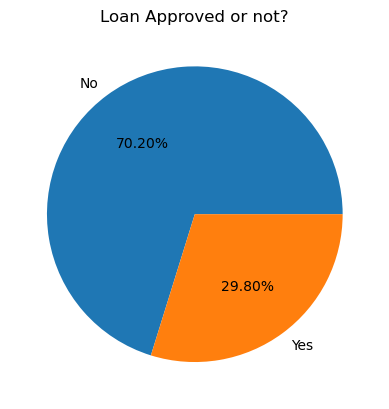

<Figure size 640x480 with 0 Axes>

In [4]:
classes_count = loan_data["Loan_Approved"].value_counts() # this function returns a list of total values in each class
print(classes_count)
plt.pie(classes_count, labels = ["No", "Yes"], autopct = "%.2f%%") # labels are 1 = Approved, 0 = Rejected
plt.title("Loan Approved or not?")
plt.show()
plt.tight_layout()

    2. analyse categorical data

Gender
Male      621
Female    379
Name: count, dtype: int64


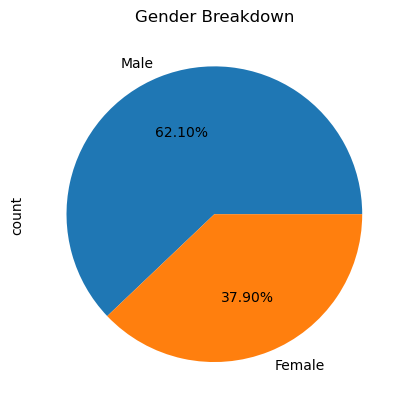

<Figure size 640x480 with 0 Axes>

In [5]:
# a). gender data

gender_count = loan_data["Gender"].value_counts() # this function returns a list of total values in each class
print(gender_count) # Male : 621,  Female : 379
gender_count.plot(  # Shortcut built directly into pandas to plot any graph in one command
    kind="pie", 
    autopct = "%.2f%%", 
    title = "Gender Breakdown"
) 
plt.show()
plt.tight_layout()

Education_Level
Graduate        722
Not Graduate    278
Name: count, dtype: int64


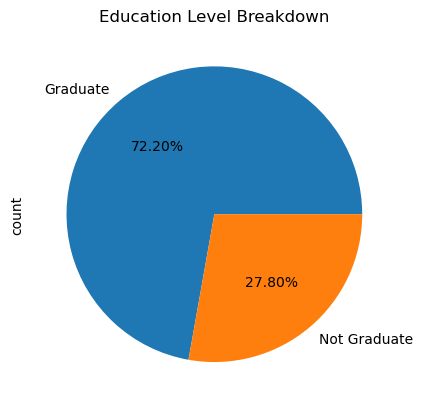

<Figure size 640x480 with 0 Axes>

In [6]:
# b). education level data

ed_count = loan_data["Education_Level"].value_counts() 
print(ed_count) # Graduate : 722, Not Graduate : 278
ed_count.plot(
    kind="pie", 
    autopct = "%.2f%%", 
    title = "Education Level Breakdown"
) 
plt.show()
plt.tight_layout()

Employment_Status
Salaried         515
Contract         213
Self-employed    182
Unemployed        90
Name: count, dtype: int64


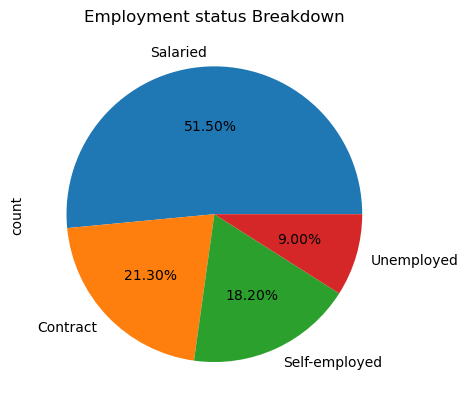

<Figure size 640x480 with 0 Axes>

In [7]:
# c). Employment status data

emp_stat_count = loan_data["Employment_Status"].value_counts()
print(emp_stat_count)
emp_stat_count.plot(
    kind="pie", 
    autopct = "%.2f%%", 
    title = "Employment status Breakdown"
) 
plt.show()
plt.tight_layout()

Marital_Status
Married    643
Single     357
Name: count, dtype: int64


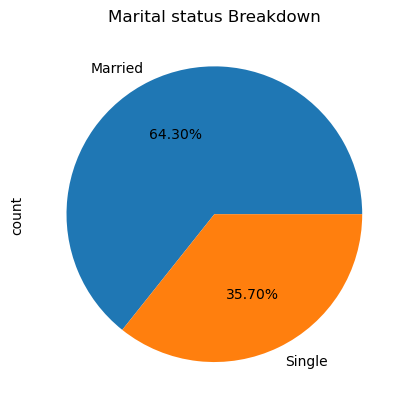

<Figure size 640x480 with 0 Axes>

In [8]:
# d). Marital status data

mar_count = loan_data["Marital_Status"].value_counts()
print(mar_count)
mar_count.plot(
    kind="pie", 
    autopct = "%.2f%%", 
    title = "Marital status Breakdown"
) 
plt.show()
plt.tight_layout()

Loan_Purpose
Business     252
Car          199
Home         190
Education    181
Personal     178
Name: count, dtype: int64


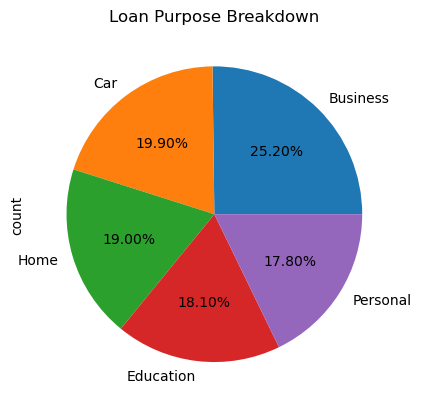

<Figure size 640x480 with 0 Axes>

In [9]:
# e). Loan Purpose data

purpose_count = loan_data["Loan_Purpose"].value_counts()
print(purpose_count)
purpose_count.plot(
    kind="pie", 
    autopct = "%.2f%%", 
    title = "Loan Purpose Breakdown"
) 
plt.show()
plt.tight_layout()

Property_Area
Urban        517
Rural        294
Semiurban    189
Name: count, dtype: int64


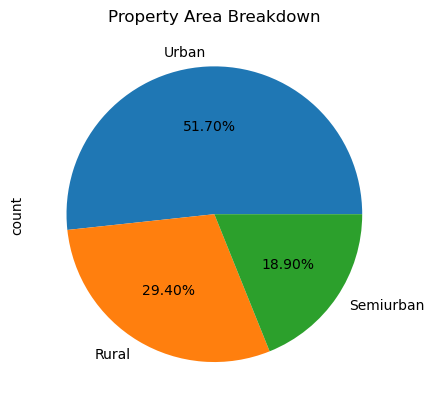

<Figure size 640x480 with 0 Axes>

In [10]:
# f). Property area data

prop_area_count = loan_data["Property_Area"].value_counts()
print(prop_area_count)
prop_area_count.plot(
    kind="pie", 
    autopct = "%.2f%%", 
    title = "Property Area Breakdown"
) 
plt.show()
plt.tight_layout()

Employer_Category
Private       422
Government    202
MNC           144
Business      135
Unemployed     97
Name: count, dtype: int64


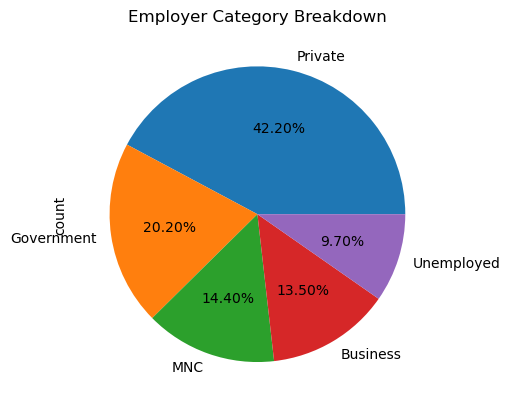

<Figure size 640x480 with 0 Axes>

In [11]:
# g). Employer Category data

emp_cat_count = loan_data["Employer_Category"].value_counts()
print(emp_cat_count)
emp_cat_count.plot(
    kind="pie", 
    autopct = "%.2f%%", 
    title = "Employer Category Breakdown"
) 
plt.show()
plt.tight_layout()

    3. Analyse income as in it the most important when applying for loan

Text(0.5, 1.0, 'Applicant Income Data')

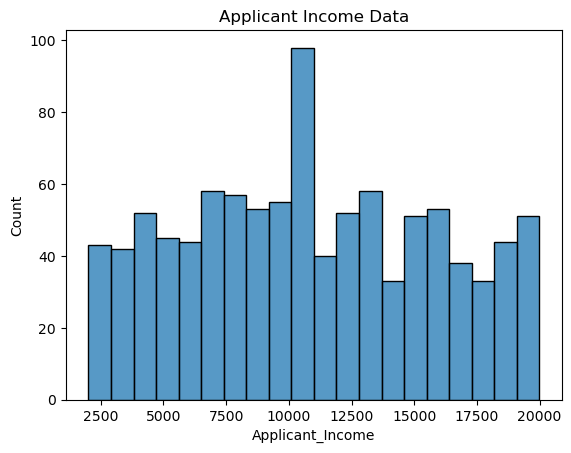

In [12]:
# applicant income

sns.histplot(
    data = loan_data,
    x = "Applicant_Income" ,
    bins = 20,
)
plt.title("Applicant Income Data")

Text(0.5, 1.0, 'Co-Applicant Income Data')

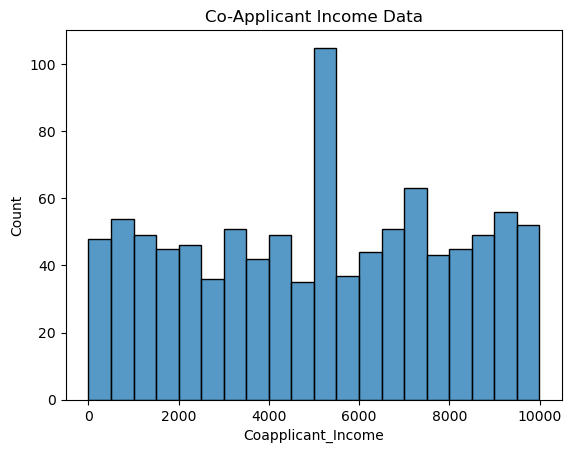

In [13]:
# co applicant income

sns.histplot(
    data = loan_data,
    x = "Coapplicant_Income" ,
    bins = 20,
)
plt.title("Co-Applicant Income Data")

    4. Look for outlier detection (can use box plots)

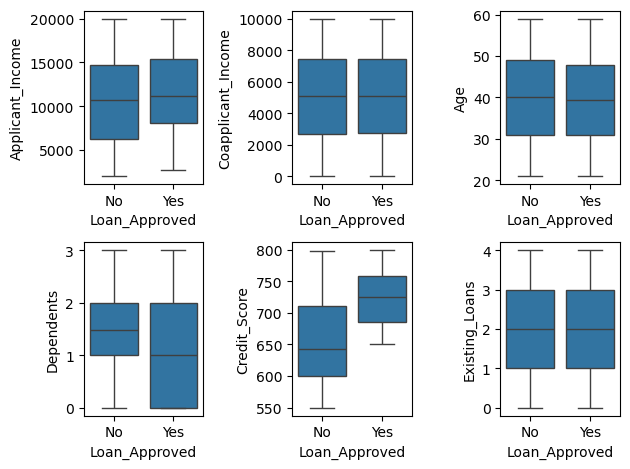

In [14]:
fig, axes = plt.subplots(2,3)

# 1. Applicant_Income
sns.boxplot(
    ax = axes[0,0],
    data = loan_data,
    x = "Loan_Approved", 
    y = "Applicant_Income"
)

# 2. Coapplicant_Income
sns.boxplot(
    ax = axes[0,1],
    data = loan_data,
    x = "Loan_Approved", 
    y = "Coapplicant_Income"
)

# 3. Age
sns.boxplot(
    ax = axes[0,2],
    data = loan_data,
    x = "Loan_Approved", 
    y = "Age"
)

# 4. Dependents
sns.boxplot(
    ax = axes[1,0],
    data = loan_data,
    x = "Loan_Approved", 
    y = "Dependents"
)

# 5. Credit_Score
sns.boxplot(
    ax = axes[1,1],
    data = loan_data,
    x = "Loan_Approved", 
    y = "Credit_Score"
)

# 6. Existing_Loans
sns.boxplot(
    ax = axes[1,2],
    data = loan_data,
    x = "Loan_Approved", 
    y = "Existing_Loans"
)	

plt.tight_layout()
# plt.savefig("box plots 1 to 6")
plt.show()

- applicant income, coapplicant income, age and existing loans are quite similar for YES and NO
- we can see a pattern amongst Dependents where most people who got YES had 0 or 1 dependents
- we can see a pattern in the credit score as well where higher than 700 credit score generally got a YES

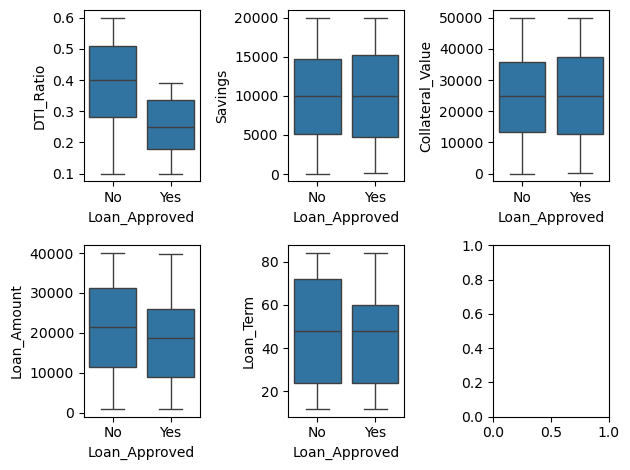

In [15]:
fig, axes = plt.subplots(2,3)

# 7. DTI_Ratio
sns.boxplot(
    ax = axes[0,0],
    data = loan_data,
    x = "Loan_Approved", 
    y = "DTI_Ratio"
)

# 8. Savings
sns.boxplot(
    ax = axes[0,1],
    data = loan_data,
    x = "Loan_Approved", 
    y = "Savings"
)

# 9. Collateral_Value
sns.boxplot(
    ax = axes[0,2],
    data = loan_data,
    x = "Loan_Approved", 
    y = "Collateral_Value"
)

# 10. Loan_Amount
sns.boxplot(
    ax = axes[1,0],
    data = loan_data,
    x = "Loan_Approved", 
    y = "Loan_Amount"
)

# 11. Loan_Term
sns.boxplot(
    ax = axes[1,1],
    data = loan_data,
    x = "Loan_Approved", 
    y = "Loan_Term"
)

plt.tight_layout()
# plt.savefig("box plots 7 to 11")
plt.show()

- graphs for savings, collateral_value, Loan_amount are quite same for YES and NO
- for DTI_Ratio, the lower is better, less than 0.35 generally got YES
- for Loan_term, higher than 60 got NO almost everytime

---

## <u>Feature Encoding</u>

    1. remove applicant id as it is useless

In [16]:
loan_data = loan_data.drop(columns = ["Applicant_ID"])

    2. Encode the categorical data (numerical, One Hot)

In [17]:
# we have learned numerical encoding through .map and one hot encoding through .get_dummies, but we will use sklearn functions

# 1. for numerical encoding we use LabelEncoder from sklearn, it assigns an integer for each category, used for ordinal data
le = LabelEncoder()
loan_data["Education_Level"] = le.fit_transform(loan_data["Education_Level"])
loan_data["Loan_Approved"] = le.fit_transform(loan_data["Loan_Approved"]) # the numbers are assigned acc. to alphabetical order

# 2. for one hot endoing we use OneHotEncoder from sklearn, it creates a binary column for each category, used for nominal data
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

# step - a : make encoder
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore") # sparse_output=False gives array instead of matrix
ohe.set_output(transform="pandas") # Force Sklearn to return a pandas df instead of np.array

# step - b : Fit and transform the target columns directly into a clean df
encoded_loan_data = ohe.fit_transform(loan_data[cols])

# step - c : Delete the old columns and Concatenate the new encoded columns back with the rest of the original data
loan_data = pd.concat([loan_data.drop(columns=cols), encoded_loan_data], axis=1) # axis = 1 to replace cols and not rows


---

## <u>Correlation Heatmap</u>

- It is a visual representation of relationships between numerical values of a dataset
- It shows Correlation Coefficient (r) between 2 numeric variables
- ranges from -1 to 1
    - 1 is perfect positive correlation
    - (-1) is perfect negative correlation
    - 0 is no linear correlation
- positive correlation Means $X_1$ and $X_2$ move in the same direction (as one goes up, the other tends to go up).
- negative correlation Means $X_1$ and $X_2$ move in opposite directions (as one goes up, the other tends to go down).

<Axes: >

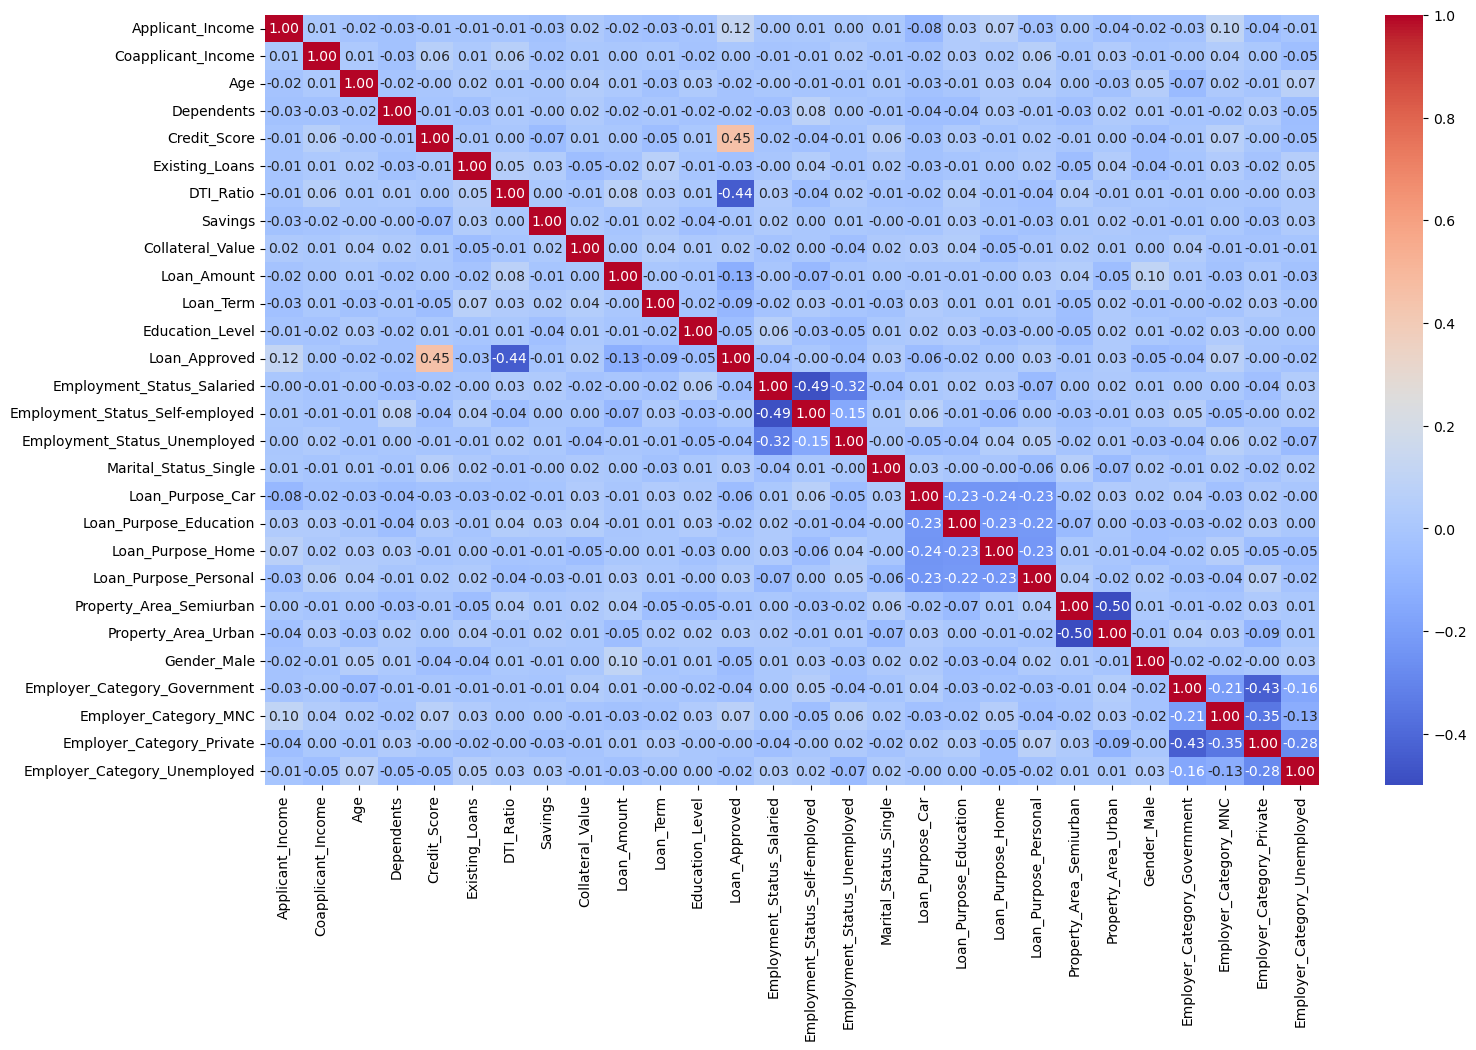

In [18]:
num_cols = loan_data.select_dtypes(include="number") # extract the numerical columns
corr_matrix = num_cols.corr() # create a correaltion matrix

# heatmap of the correlation matrix
plt.figure(figsize=(17,10))
sns.heatmap(
    corr_matrix,
    annot = True, # labels
    fmt = ".2f", # decimal places
    cmap="coolwarm"
)
# plt.savefig("correlation_heatmap")

- Findings from the heatmap
    - Multicollinearity: Dark colors mean redundant features repeat identical information, confusing linear models.
        - To solve it we do :
            1. PCA
            2. dimension reduction
            3. feature selection
    - Feature Independence: Light blue means uncorrelated features, keeping key signals clean and unique, good for linear models

In [19]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False) # shows the correlation matrix with the loan approved column 

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

- findings of the correlation matrix with the approved_loan column (label)
  
    - Credit Score (0.451): Strongest positive predictor, higher credit scores correlate strongly with loan approval.
    
    - DTI Ratio (-0.445): Strongest negative predictor, a lower debt-to-income ratio significantly boosts approval odds.
    
    - Loan Amount (-0.126): Clear negative correlation, larger requested loan amounts carry higher rejection rates.
    
    - Applicant Income (0.119): Mild positive correlation, higher income helps but matters less than credit health.
    
    - Loan Term (-0.086): Weak negative correlation, longer repayment timelines are flagged as slightly riskier.
    
    - Employer Category (MNC) (0.069): Very low positive impact, working at an MNC offers a tiny edge for approval.
    
    - Demographics (-0.05): Gender and education show negligible correlation, meaning they barely affect decisions.
    
    - Noise (0.00): Coapplicant income, savings, and age have zero straight-line relationship with loan approval.

---

## Feature Scaling and Train_Test_Split

In [20]:
X = loan_data.drop(columns = ["Loan_Approved"]) # 27 features here, we can predict that knn wont do well as the output will be sparse
y = loan_data["Loan_Approved"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---

## Train Models and Evaluate

    1. Logistic Regression (2nd best)

In [21]:
# create, fit and predict 

lgr_model = LogisticRegression(max_iter = 1000) # it does l2 regularization by default
lgr_model.fit(X_train_scaled, y_train)
y_pred = lgr_model.predict(X_test_scaled)

# evaluate
# normally we take accuracy as main evaluation metric but here will take a close look at the problem statement

# 1. Good customers sometimes get rejected, leading to loss of business. (priority 2)
# 2. High-risk customers sometimes get approved, leading to financial losses. (priority 1)

# for priority 1, it has false positives and therefore precision score would matter a lot (precision = tp / (tp + fp))
# for priority 2, it has false negatives and therefor recall score would matter a lot (recall = tp / (tp + fn))

print("For Logistic Regression :-\n")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred)) # inversely propotional with precision
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", f1_score(y_test, y_pred)) # balances recall and precision
print("\nConfusion Matrix : \n", confusion_matrix(y_test, y_pred))

For Logistic Regression :-

Precision :  0.7833333333333333
Recall :  0.7704918032786885
Accuracy :  0.865
F1 Score :  0.7768595041322314

Confusion Matrix : 
 [[126  13]
 [ 14  47]]


In [22]:
# try with  L1 regularization
# L1 regularization is famous for doing Automatic Feature Selection
lgr_L1_model = LogisticRegression(penalty = "l1", solver = "saga",max_iter = 1000)
lgr_L1_model.fit(X_train_scaled, y_train)
y_pred = lgr_L1_model.predict(X_test_scaled)

# evaluate

print("For Logistic Regression (L1) :-\n")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", f1_score(y_test, y_pred)) 
print("\nConfusion Matrix : \n", confusion_matrix(y_test, y_pred))

For Logistic Regression (L1) :-

Precision :  0.7868852459016393
Recall :  0.7868852459016393
Accuracy :  0.87
F1 Score :  0.7868852459016393

Confusion Matrix : 
 [[126  13]
 [ 13  48]]


    2. Gaussian Naive Bayes (Winner)

In [23]:
# create, fit and predict

gnb_model = GaussianNB()
gnb_model.fit(X_train_scaled, y_train)
y_pred = gnb_model.predict(X_test_scaled)

# evaluate

print("For Gaussian Naive Bayes :-\n")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", f1_score(y_test, y_pred))
print("\nConfusion Matrix : \n", confusion_matrix(y_test, y_pred))

# Note : Mathematically, Naive Bayes is scale-invariant. But computationally, Scikit-Learn's 
#        GaussianNB requires scaling if your features have wildly different ranges to protect 
#        it from its own variance-smoothing safety net.

For Gaussian Naive Bayes :-

Precision :  0.8035714285714286
Recall :  0.7377049180327869
Accuracy :  0.865
F1 Score :  0.7692307692307693

Confusion Matrix : 
 [[128  11]
 [ 16  45]]


    3. KNN model (Worst due to curse of dimensionality)

In [24]:
# create normally, fit and predict

knn_model = KNeighborsClassifier(n_neighbors = 5) 
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

# evaluate

print("For KNN (normal) :-\n")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", f1_score(y_test, y_pred))
print("\nConfusion Matrix : \n", confusion_matrix(y_test, y_pred))

For KNN (normal) :-

Precision :  0.6274509803921569
Recall :  0.5245901639344263
Accuracy :  0.76
F1 Score :  0.5714285714285714

Confusion Matrix : 
 [[120  19]
 [ 29  32]]


In [25]:
# create with the pipeline and k-fold cross validation

steps = [("scaler", StandardScaler()), ("knn",KNeighborsClassifier())]
pipeline = Pipeline(steps)

neighbors = np.arange(1, 100, 2)

param_grid = {"knn__n_neighbors" : neighbors}

scoring_metrics = {
    "precision": 'precision',
    "recall" : 'recall',
    "f1" : 'f1'
}

knn_classifier_cv = GridSearchCV(
    pipeline,
    param_grid,
    cv = 7,
    scoring = scoring_metrics,
    refit="f1"
)

knn_classifier_cv.fit(X_train, y_train)
y_pred = knn_classifier_cv.predict(X_test)

# evaluate

print("For KNN (pipeline + cross validation + scoring metrics) :-\n")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", f1_score(y_test, y_pred))
print("\nConfusion Matrix : \n", confusion_matrix(y_test, y_pred))

# results of the k-fold cross validation
results = pd.DataFrame(knn_classifier_cv.cv_results_)

print(knn_classifier_cv.best_params_)

For KNN (pipeline + cross validation + scoring metrics) :-

Precision :  0.6274509803921569
Recall :  0.5245901639344263
Accuracy :  0.76
F1 Score :  0.5714285714285714

Confusion Matrix : 
 [[120  19]
 [ 29  32]]
{'knn__n_neighbors': np.int64(5)}


- KNN Model Evaluation & Tuning Summary

    - Baseline KNN (k=5): Accuracy 76%, Recall 52%, F1 0.57. Balanced, but overall mediocre risk detection.

    - Optimized for Precision (k=69): Precision 85%, Recall 19%. Horrible at risk management; missed 49 defaults.

    - Default GridSearch (k=33): Accuracy 75%, Recall 27%. Hit the Accuracy Paradox by approving almost everyone.

    - Optimized for F1 Score: GridSearch picked k=5, proving that the very first blind guess was the best structural balance.

    - Final Verdict: KNN collapsed due to the Curse of Dimensionality. 27 features created too much empty space for distance metrics.

---

## <u>Feature Engineering and Re-evaluation</u>

In [26]:
# in correlation heatmap and comparision with labels, we saw Credit_score(+ve) and DTI_ratio(-ve) affected the labels the most
# therefore we will take the square of them and replace in the data so that they have more impact

loan_data["DTI_Ratio_sq"] = loan_data["DTI_Ratio"] ** 2
loan_data["Credit_Score_sq"] = loan_data["Credit_Score"] ** 2

# replacing from the old credit score and dti columns

X = loan_data.drop(columns=["Loan_Approved", "Credit_Score", "DTI_Ratio"])
y = loan_data["Loan_Approved"]

# train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

    1. Logistic Regression (with FE)

In [33]:
lgr_model = LogisticRegression() # it does l2 regularization by default
lgr_model.fit(X_train_scaled, y_train)
y_pred = lgr_model.predict(X_test_scaled)

print("For Logistic Regression (with FE) :-\n")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred)) # inversely propotional with precision
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", f1_score(y_test, y_pred)) # balances recall and precision
print("\nConfusion Matrix : \n", confusion_matrix(y_test, y_pred))

For Logistic Regression (with FE) :-

Precision :  0.7903225806451613
Recall :  0.8032786885245902
Accuracy :  0.875
F1 Score :  0.7967479674796748

Confusion Matrix : 
 [[126  13]
 [ 12  49]]


In [34]:
# try with  L1 regularization
# L1 regularization is famous for doing Automatic Feature Selection
lgr_L1_model = LogisticRegression(penalty = "l1", solver = "saga",max_iter = 1000)
lgr_L1_model.fit(X_train_scaled, y_train)
y_pred = lgr_L1_model.predict(X_test_scaled)

# evaluate

print("For Logistic Regression (L1) :-\n")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", f1_score(y_test, y_pred)) 
print("\nConfusion Matrix : \n", confusion_matrix(y_test, y_pred))

For Logistic Regression (L1) :-

Precision :  0.7741935483870968
Recall :  0.7868852459016393
Accuracy :  0.865
F1 Score :  0.7804878048780488

Confusion Matrix : 
 [[125  14]
 [ 13  48]]


    2. Naive Bayes (With FE)

In [29]:
# create, fit and predict

gnb_model = GaussianNB()
gnb_model.fit(X_train_scaled, y_train)
y_pred = gnb_model.predict(X_test_scaled)

# evaluate

print("For Gaussian Naive Bayes (with FE) :-\n")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", f1_score(y_test, y_pred))
print("\nConfusion Matrix : \n", confusion_matrix(y_test, y_pred))

For Gaussian Naive Bayes (with FE) :-

Precision :  0.7833333333333333
Recall :  0.7704918032786885
Accuracy :  0.865
F1 Score :  0.7768595041322314

Confusion Matrix : 
 [[126  13]
 [ 14  47]]


    3. KNN (With FE)

In [30]:
knn_model = KNeighborsClassifier(n_neighbors = 5) 
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

# evaluate

print("For KNN (normal) :-\n")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", f1_score(y_test, y_pred))
print("\nConfusion Matrix : \n", confusion_matrix(y_test, y_pred))

For KNN (normal) :-

Precision :  0.62
Recall :  0.5081967213114754
Accuracy :  0.755
F1 Score :  0.5585585585585585

Confusion Matrix : 
 [[120  19]
 [ 30  31]]
